In [72]:
import pandas as pd

file_path = '/media/shuyan/Local Disk (D:)/Github/Data/final_data_0724.csv'
df_full = pd.read_csv(file_path)

In [85]:
# select random 1000 rows
df = df_full
# make sure material weight is numeric
df['material_weight'] = pd.to_numeric(df['material_weight'], errors='coerce')
df


,year of construction of the building yyyy,building class,building system,sub system,component,material,material_weight
0,1415.0,housing,electrical system,electrical wiring and cables,electrical cable,copper,0.015936
1,1415.0,housing,electrical system,electrical wiring and cables,electrical cable,pvc,0.621487
2,1415.0,housing,heating system,heating,boiler,aluminum,1.426000
3,1415.0,housing,heating system,heating,boiler,brass,1.426000
4,1415.0,housing,heating system,heating,boiler,copper,7.130000
...,...,...,...,...,...,...,...
2582451,2017.0,housing,plumbing system,drainage and waste pipes,water pipe,zinc coating,0.000000
2582452,2017.0,housing,plumbing system,water supply pipes and fixtures,water pipe,copper,0.000000
2582453,2017.0,housing,plumbing system,water supply pipes and fixtures,water pipe,pex,0.000000
2582454,2017.0,housing,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000


In [86]:
import pandas as pd
df_final = df
# exclude historical buildings before 1930
df_final_wt_hb = df_final[df_final['year of construction of the building yyyy'] >= 1930]
# exclude buildings newer than 2020
df_final_wt_hb = df_final_wt_hb[df_final_wt_hb['year of construction of the building yyyy'] <= 2020]
df_final_wt_hb

,year of construction of the building yyyy,building class,building system,sub system,component,material,material_weight
4866,1930.0,housing,electrical system,electrical wiring and cables,electrical cable,copper,0.864042
4867,1930.0,housing,electrical system,electrical wiring and cables,electrical cable,pvc,33.697634
4868,1930.0,housing,heating system,heating,boiler,aluminum,83.080000
4869,1930.0,housing,heating system,heating,boiler,brass,83.080000
4870,1930.0,housing,heating system,heating,boiler,copper,415.400000
...,...,...,...,...,...,...,...
2582451,2017.0,housing,plumbing system,drainage and waste pipes,water pipe,zinc coating,0.000000
2582452,2017.0,housing,plumbing system,water supply pipes and fixtures,water pipe,copper,0.000000
2582453,2017.0,housing,plumbing system,water supply pipes and fixtures,water pipe,pex,0.000000
2582454,2017.0,housing,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000


In [87]:
# hide warnings
import warnings
warnings.filterwarnings('ignore')

# # Define component lifespan
# component_lifespan = {
#     'electrical cable': 30,
#     'boiler': 20,
#     'water pipe': 50,
#     'air duct': 25,
#     'radiator': 40,
#     'heat pump': 15,
# }
# Define component lifespan
component_lifespan = {
    'electrical cable': 80,
    'boiler': 80,
    'water pipe': 80,
    'air duct': 80,
    'radiator': 80,
    'heat pump': 80,
}

# Define future decades
future_decades = [f"{2024 + i*10}-{2034 + i*10}" for i in range(5)]  # You can adjust the range as needed

# Calculate end-of-life decade
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year of construction of the building yyyy'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)

# Create columns for each future decade and initialize with zero
for decade in future_decades:
    df[decade] = 0

# Populate the future decade columns with material weights based on end-of-life year
for index, row in df.iterrows():
    start_year= row['year of construction of the building yyyy']
    end_year = row['end_of_life_year']
    
    for decade in future_decades:
        start, end = map(int, decade.split('-'))
        
        if start_year < end <= end_year:
            df.at[index, decade] = row['material_weight']


df.drop(columns=['year of construction of the building yyyy'], inplace=True)
# Group by future_decade and other relevant columns and sum the material weights
df_aggregated = df.groupby(['building class', 'building system', 'component', 'material','2024-2034','2034-2044','2044-2054','2054-2064','2064-2074']).agg({'material_weight': 'sum'}).reset_index()
df_aggregated

,building class,building system,component,material,2024-2034,2034-2044,2044-2054,2054-2064,2064-2074,material_weight
0,housing,electrical system,electrical cable,copper,0.000000e+00,0.000000e+00,0.0,0,0,1.230123e+04
1,housing,electrical system,electrical cable,copper,6.248088e-05,0.000000e+00,0.0,0,0,6.248088e-05
2,housing,electrical system,electrical cable,copper,1.093176e-03,0.000000e+00,0.0,0,0,1.093176e-03
3,housing,electrical system,electrical cable,copper,1.137561e-03,0.000000e+00,0.0,0,0,1.137561e-03
4,housing,electrical system,electrical cable,copper,1.252706e-03,0.000000e+00,0.0,0,0,1.252706e-03
...,...,...,...,...,...,...,...,...,...,...
47108,other,ventilation system,air duct,wire,1.147776e+07,1.147776e+07,0.0,0,0,1.147776e+07
47109,other,ventilation system,air duct,wire,1.176397e+07,0.000000e+00,0.0,0,0,1.176397e+07
47110,other,ventilation system,air duct,wire,1.340746e+07,1.340746e+07,0.0,0,0,1.340746e+07
47111,other,ventilation system,air duct,wire,1.657897e+07,0.000000e+00,0.0,0,0,1.657897e+07


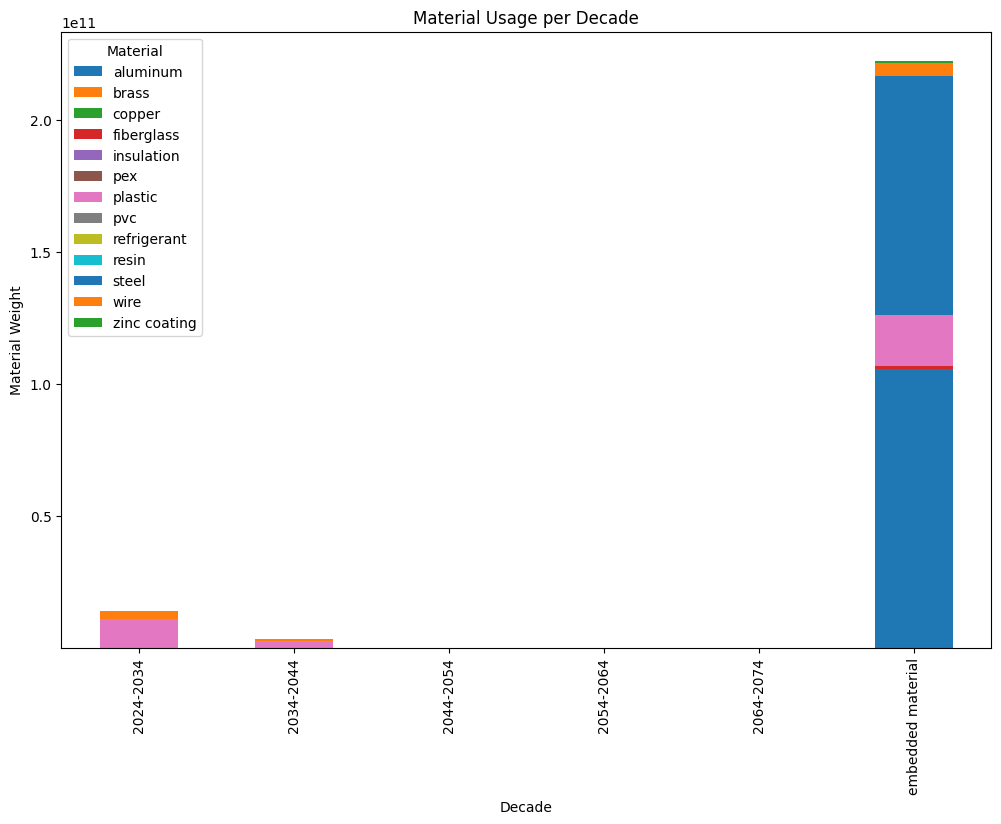

In [90]:
import matplotlib.pyplot as plt
# rename the column of material_weight
df_aggregated.rename(columns={'material_weight':'embedded material'}, inplace=True)
# Fixing the error by ensuring all relevant columns are numeric
# Convert the relevant columns to numeric, setting errors='coerce' to handle non-numeric values gracefully
decade_columns = ['embedded material','2024-2034', '2034-2044', '2044-2054', '2054-2064', '2064-2074']
# decade_columns = ['2024-2034', '2034-2044', '2044-2054', '2054-2064', '2064-2074']
df_aggregated[decade_columns] = df_aggregated[decade_columns].apply(pd.to_numeric, errors='coerce')

# Pivot the dataframe to get the sum of materials per decade
pivot_df = df_aggregated.pivot_table(index='material', values=decade_columns, aggfunc='sum')

# Plot the stacked bar chart
pivot_df.T.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Material Usage per Decade')
plt.xlabel('Decade')
plt.ylabel('Material Weight')
plt.legend(title='Material')
plt.show()

In [37]:
# # Normalize the data to better visualize smaller values
# pivot_df_normalized = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# # Plot the normalized stacked bar chart
# pivot_df_normalized.T.plot(kind='bar', stacked=True, figsize=(12, 8))
# plt.title('Normalized Material Usage per Decade')
# plt.xlabel('Decade')
# plt.ylabel('Normalized Material Weight')
# plt.legend(title='Material')
# plt.show()

# Test

In [77]:
# select random 1000 rows
df = df_full.sample(n=10000, random_state=1)
# make sure material weight is numeric
df['material_weight'] = pd.to_numeric(df['material_weight'], errors='coerce')
df


,year of construction of the building yyyy,building class,building system,sub system,component,material,material_weight
1536697,1907.0,housing,heating system,heating,heat pump,refrigerant,0.000000
2025041,1926.0,housing,heating system,heating,heat pump,copper,0.000000
38730,1858.0,housing,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000
2483407,1970.0,office,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000
1885764,1906.0,other,plumbing system,water supply pipes and fixtures,water pipe,pex,0.000000
...,...,...,...,...,...,...,...
1579283,1927.0,other,electrical system,electrical wiring and cables,electrical cable,copper,0.890812
1120750,2003.0,housing,heating system,heating,radiator,plastic,200.400000
1963767,1944.0,other,plumbing system,drainage and waste pipes,water pipe,steel,0.000000
2275565,1935.0,housing,plumbing system,water supply pipes and fixtures,water pipe,zinc coating,0.000000


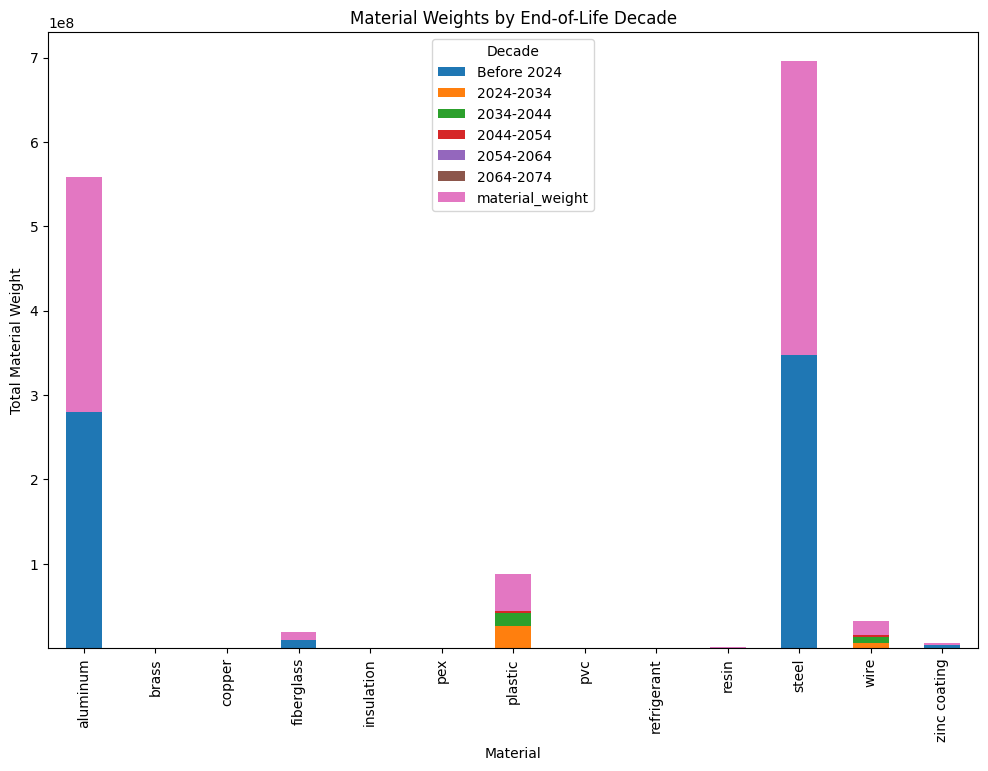

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# Define component lifespan
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define future decades
future_decades = [f"{2024 + i*10}-{2034 + i*10}" for i in range(6)]  # You can adjust the range as needed

# Calculate end-of-life decade
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year of construction of the building yyyy'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)

# Create columns for each future decade and initialize with zero
for decade in future_decades:
    df[decade] = 0

# Adding the 'Before 2024' column
df['Before 2024'] = 0

# Populate the future decade columns with material weights based on end-of-life year
for index, row in df.iterrows():
    start_year= row['year of construction of the building yyyy']
    end_year = row['end_of_life_year']
    
    if end_year < 2024:
        df.at[index, 'Before 2024'] = row['material_weight']
    else:
        for decade in future_decades:
            start, end = map(int, decade.split('-'))
            
            if start <= end_year < end:
                df.at[index, decade] = row['material_weight']

# Dropping the original year column
df.drop(columns=['year of construction of the building yyyy'], inplace=True)

# Group by future_decade and other relevant columns and sum the material weights
df_aggregated = df.groupby(['building class', 'building system', 'component', 'material', 'Before 2024', '2024-2034', '2034-2044', '2044-2054', '2054-2064', '2064-2074']).agg({'material_weight': 'sum'}).reset_index()

# Plotting the stacked bar chart
material_groups = df_aggregated.groupby('material').sum()

# Plotting
ax = material_groups.plot(kind='bar', stacked=True, figsize=(12, 8))

plt.title('Material Weights by End-of-Life Decade')
plt.xlabel('Material')
plt.ylabel('Total Material Weight')
plt.legend(title='Decade')
plt.show()

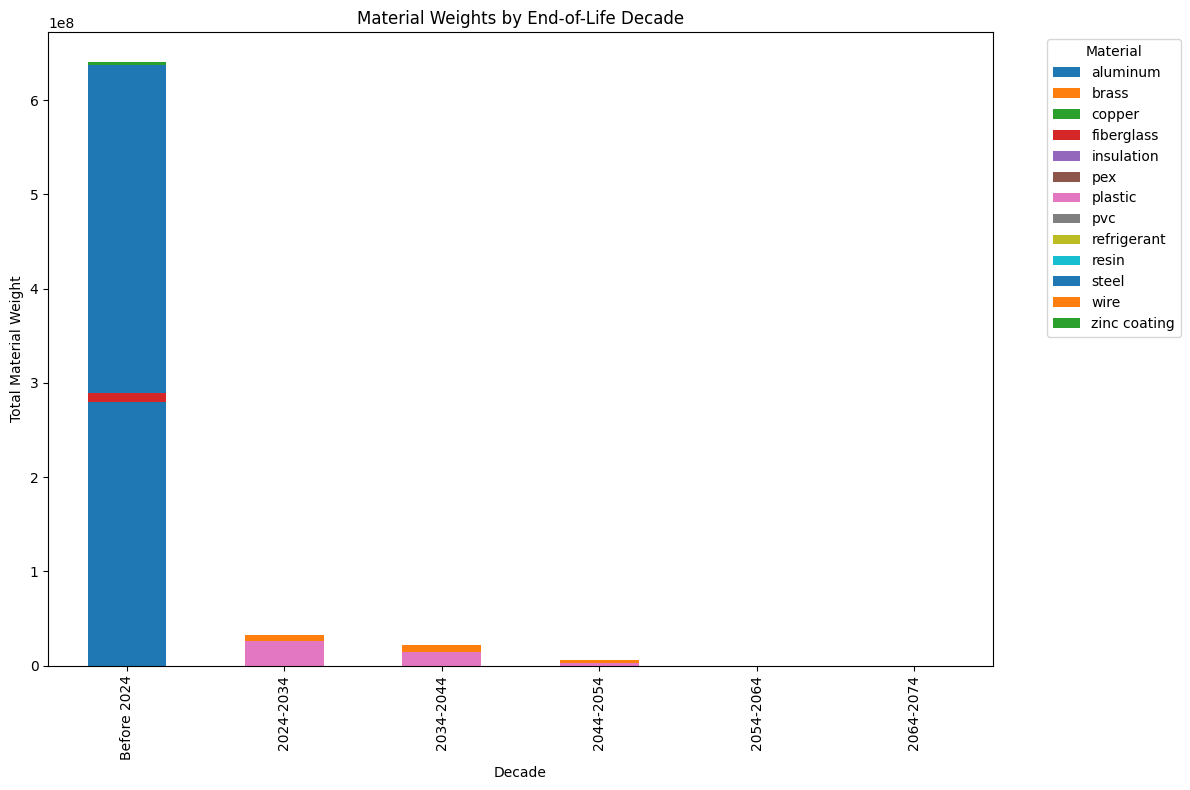

In [79]:
# Grouping by material and summing the material weights for each decade, including 'Before 2024'
decades_columns = ['Before 2024', '2024-2034', '2034-2044', '2044-2054', '2054-2064', '2064-2074']
df_decade_aggregated = df.groupby('material')[decades_columns].sum()

# Plotting the stacked bar chart with columns in decades
ax = df_decade_aggregated.T.plot(kind='bar', stacked=True, figsize=(12, 8))

plt.title('Material Weights by End-of-Life Decade')
plt.xlabel('Decade')
plt.ylabel('Total Material Weight')
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Test Reuse

In [80]:
# select random 1000 rows
df = df_full.sample(n=10000, random_state=1)
# make sure material weight is numeric
df['material_weight'] = pd.to_numeric(df['material_weight'], errors='coerce')
df

,year of construction of the building yyyy,building class,building system,sub system,component,material,material_weight
1536697,1907.0,housing,heating system,heating,heat pump,refrigerant,0.000000
2025041,1926.0,housing,heating system,heating,heat pump,copper,0.000000
38730,1858.0,housing,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000
2483407,1970.0,office,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000
1885764,1906.0,other,plumbing system,water supply pipes and fixtures,water pipe,pex,0.000000
...,...,...,...,...,...,...,...
1579283,1927.0,other,electrical system,electrical wiring and cables,electrical cable,copper,0.890812
1120750,2003.0,housing,heating system,heating,radiator,plastic,200.400000
1963767,1944.0,other,plumbing system,drainage and waste pipes,water pipe,steel,0.000000
2275565,1935.0,housing,plumbing system,water supply pipes and fixtures,water pipe,zinc coating,0.000000


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
# rename year column
df.rename(columns={'year of construction of the building yyyy':'year_of_construction'}, inplace=True)
# remove rows with missing values in material_weight
df = df.dropna(subset=['material_weight'])

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# # Define percentage distributions based on material
# material_distributions = {
#     "copper": {"reuse": 0.20, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.10},
#     "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
#     "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
#     "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
#     "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
#     "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
#     "steel": {"reuse": 0.15, "recycle": 0.75, "refurbish": 0.10, "disposal": 0.0},
# }

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] #* material_dist['reuse']
        recycle = component_dist['recycle'] #* material_dist['recycle']
        refurbish = component_dist['refurbish'] #* material_dist['refurbish']
        disposal = component_dist['disposal'] #* material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        if total > 0:
            row['reuse'] = reuse / total
            row['recycle'] = recycle / total
            row['refurbish'] = refurbish / total
            row['disposal'] = disposal / total
        else:
            row['reuse'] = 0
            row['recycle'] = 0
            row['refurbish'] = 0
            row['disposal'] = 1
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)
df


,year_of_construction,building class,building system,sub system,component,material,material_weight,reuse,recycle,refurbish,disposal
1536697,1907.0,housing,heating system,heating,heat pump,refrigerant,0.000000,0.0,0.0,0.0,1.0
2025041,1926.0,housing,heating system,heating,heat pump,copper,0.000000,0.0,0.0,0.0,1.0
38730,1858.0,housing,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000,0.0,0.0,0.0,1.0
2483407,1970.0,office,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000,0.0,0.0,0.0,1.0
1885764,1906.0,other,plumbing system,water supply pipes and fixtures,water pipe,pex,0.000000,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1579283,1927.0,other,electrical system,electrical wiring and cables,electrical cable,copper,0.890812,0.0,0.0,0.0,1.0
1120750,2003.0,housing,heating system,heating,radiator,plastic,200.400000,0.0,0.0,0.0,1.0
1963767,1944.0,other,plumbing system,drainage and waste pipes,water pipe,steel,0.000000,0.0,0.0,0.0,1.0
2275565,1935.0,housing,plumbing system,water supply pipes and fixtures,water pipe,zinc coating,0.000000,0.0,0.0,0.0,1.0


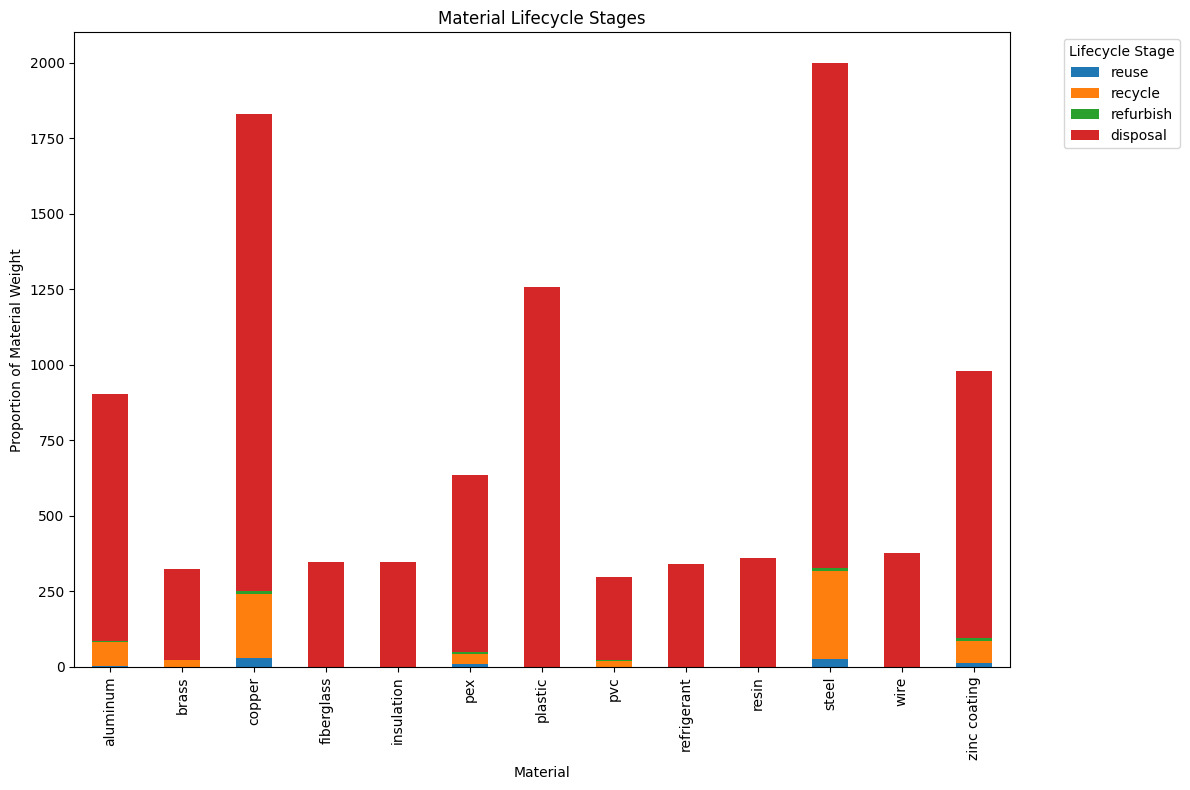

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# Grouping by material and summing the material weights for each lifecycle stage
lifecycle_stages = ['reuse', 'recycle', 'refurbish', 'disposal']
df_lifecycle = df.groupby('material')[lifecycle_stages].sum()

# Plotting the stacked bar chart for lifecycle stages
ax = df_lifecycle.plot(kind='bar', stacked=True, figsize=(12, 8))

plt.title('Material Lifecycle Stages')
plt.xlabel('Material')
plt.ylabel('Proportion of Material Weight')
plt.legend(title='Lifecycle Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

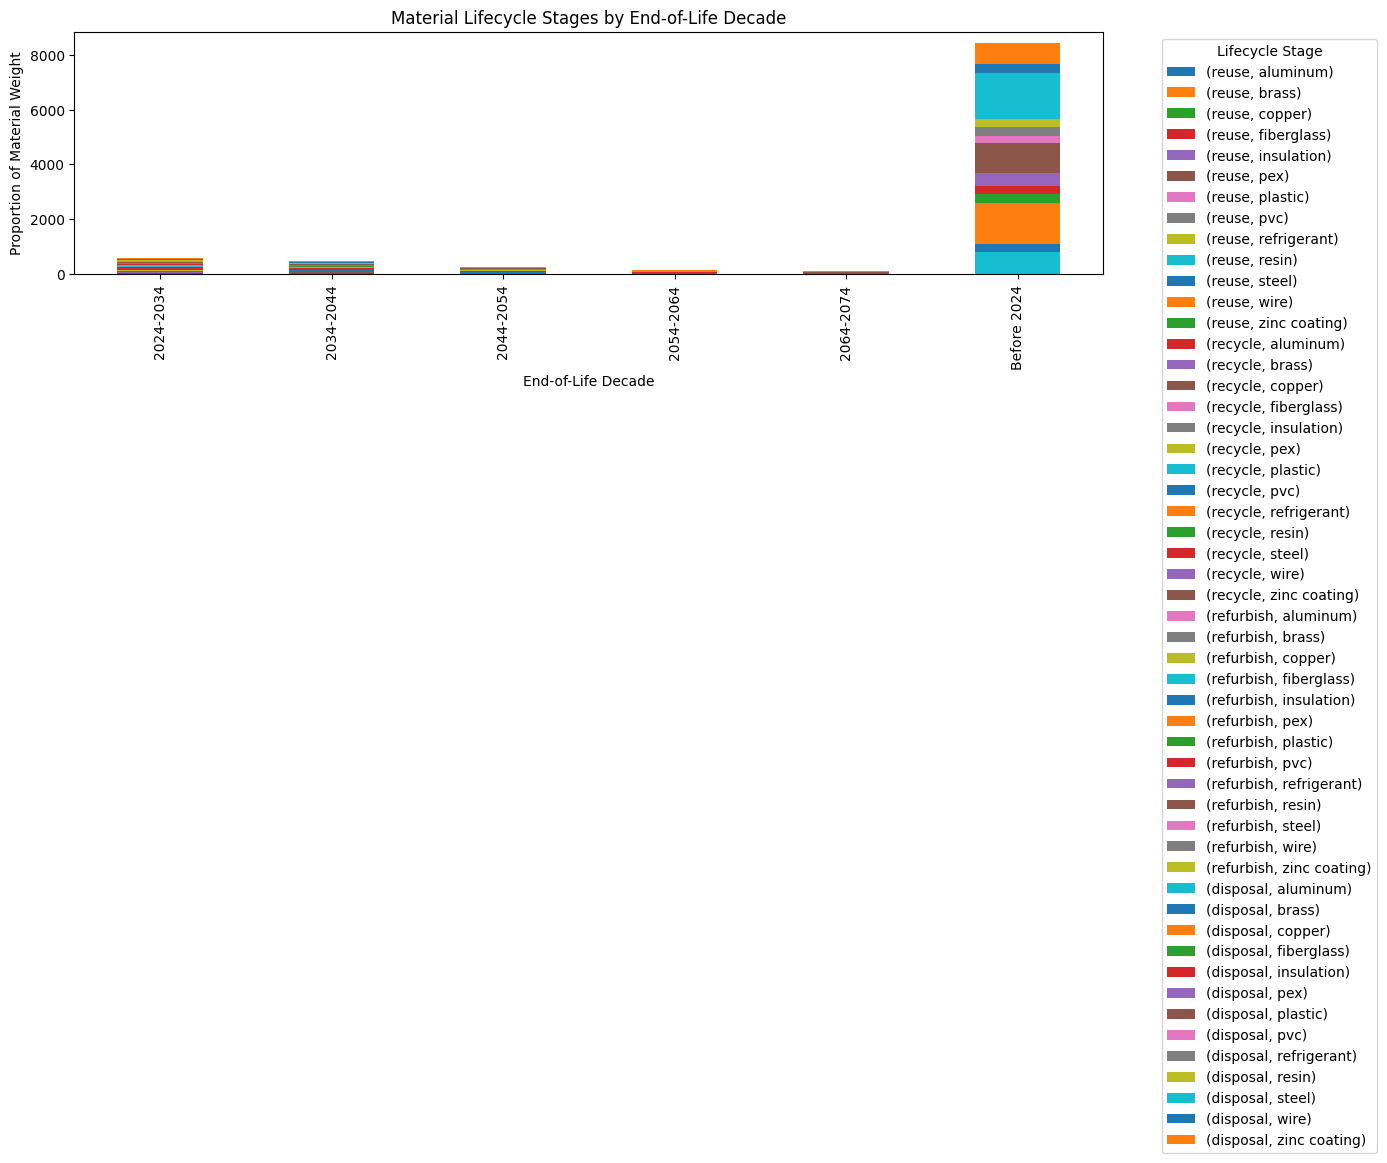

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Define component lifespan
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Calculate end-of-life year
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year_of_construction'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)

# Define future decades
future_decades = [f"{2024 + i*10}-{2034 + i*10}" for i in range(5)]  # You can adjust the range as needed

# Assign end-of-life decade
def assign_decade(end_of_life_year):
    for decade in future_decades:
        start, end = map(int, decade.split('-'))
        if start <= end_of_life_year < end:
            return decade
    return 'Before 2024' if end_of_life_year < 2024 else 'After 2074'

df['end_of_life_decade'] = df['end_of_life_year'].apply(assign_decade)

# Aggregating material weights by end-of-life decade and lifecycle stage
df_aggregated = df.groupby(['end_of_life_decade', 'material'])[['reuse', 'recycle', 'refurbish', 'disposal']].sum().reset_index()

# Pivot the dataframe for plotting
df_pivot = df_aggregated.pivot(index='end_of_life_decade', columns='material', values=['reuse', 'recycle', 'refurbish', 'disposal']).fillna(0)

# Plotting the stacked bar chart for lifecycle stages by end-of-life decade
ax = df_pivot.plot(kind='bar', stacked=True, figsize=(14, 8))

plt.title('Material Lifecycle Stages by End-of-Life Decade')
plt.xlabel('End-of-Life Decade')
plt.ylabel('Proportion of Material Weight')
plt.legend(title='Lifecycle Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

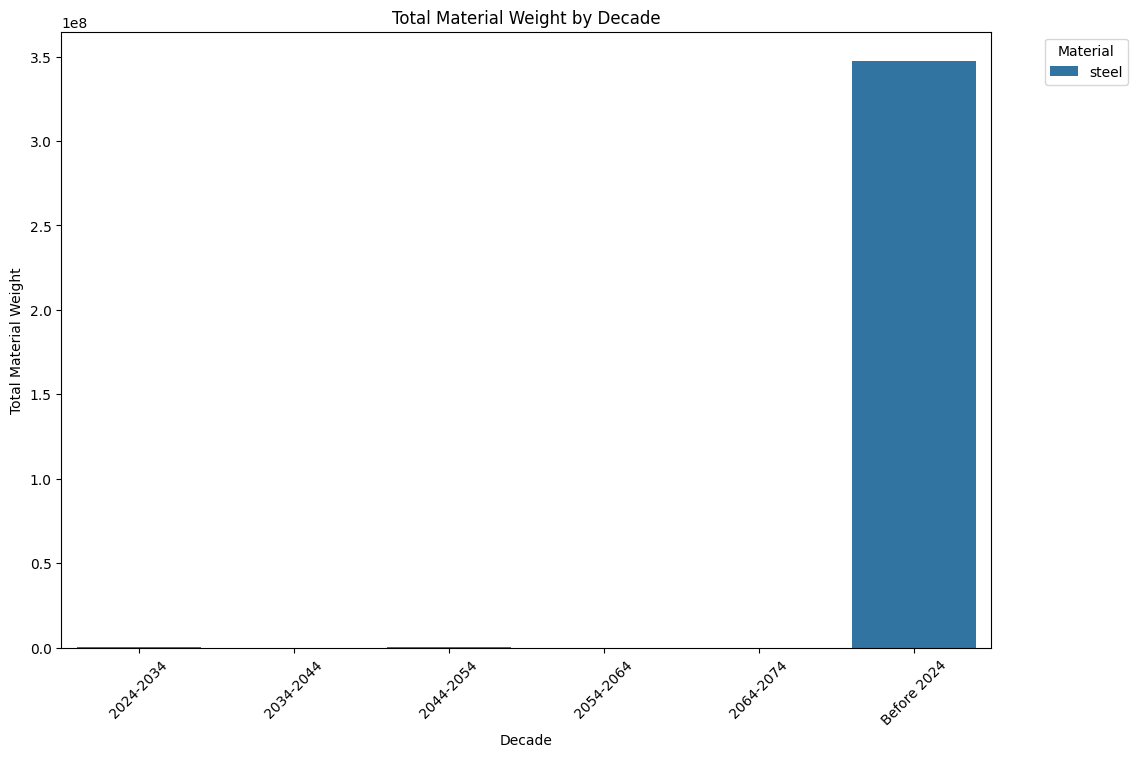

In [84]:

# select only steel
df = df[df['material'] == 'steel']


# Multiplying the values by each stream
for stream in ['reuse', 'recycle', 'refurbish', 'disposal']:
    df[stream] = df[stream] * df['material_weight']
    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Calculate the decade for each end-of-life year
df['decade'] = (df['end_of_life_year'] // 10) * 10

# Group by material and decade, summing the material weights
decade_material_weights = df.groupby(['end_of_life_decade', 'material'])['material_weight'].sum().reset_index()

# Plot a histogram using Seaborn
plt.figure(figsize=(12, 8))
sns.barplot(x='end_of_life_decade', y='material_weight', hue='material', data=decade_material_weights)
plt.xlabel('Decade')
plt.ylabel('Total Material Weight')
plt.title('Total Material Weight by Decade')
plt.xticks(rotation=45)
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()